'pip' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
# %% [Cell 1] Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# %% [Cell 2] Load data + basic info
DATA_PATH = r"C:\Users\admin\Downloads\Concrete compressive strength (6).csv"  # change path if needed

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (1030, 9)

Head:
    cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0            1040.0            676.0   28                          79.99  
1            1055.0            676.0   28                          61.89  
2             932.0            594.0  270                          40.27  
3             932.0            594.0  365                          41.05  
4             978.4            825.5  360                          44.30  

Dtypes:
 cement                           float64
blast_furnace_slag               float64
fly_ash                       

In [4]:
# %% [Cell 3] Clean data - nulls + IQR outlier removal
print("Rows before cleaning:", df.shape[0])

# Handle nulls
df = df.dropna()
print("Rows after dropping nulls:", df.shape[0])

# IQR outlier removal (applied to all numeric columns)
def remove_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

rows_before = df.shape[0]
numeric_cols = df.columns.tolist()
df = remove_outliers_iqr(df, numeric_cols)
rows_after = df.shape[0]

print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

df = df.reset_index(drop=True)

Rows before cleaning: 926
Rows after dropping nulls: 926
Rows before outlier removal: 926
Rows after outlier removal: 753
Rows removed: 173


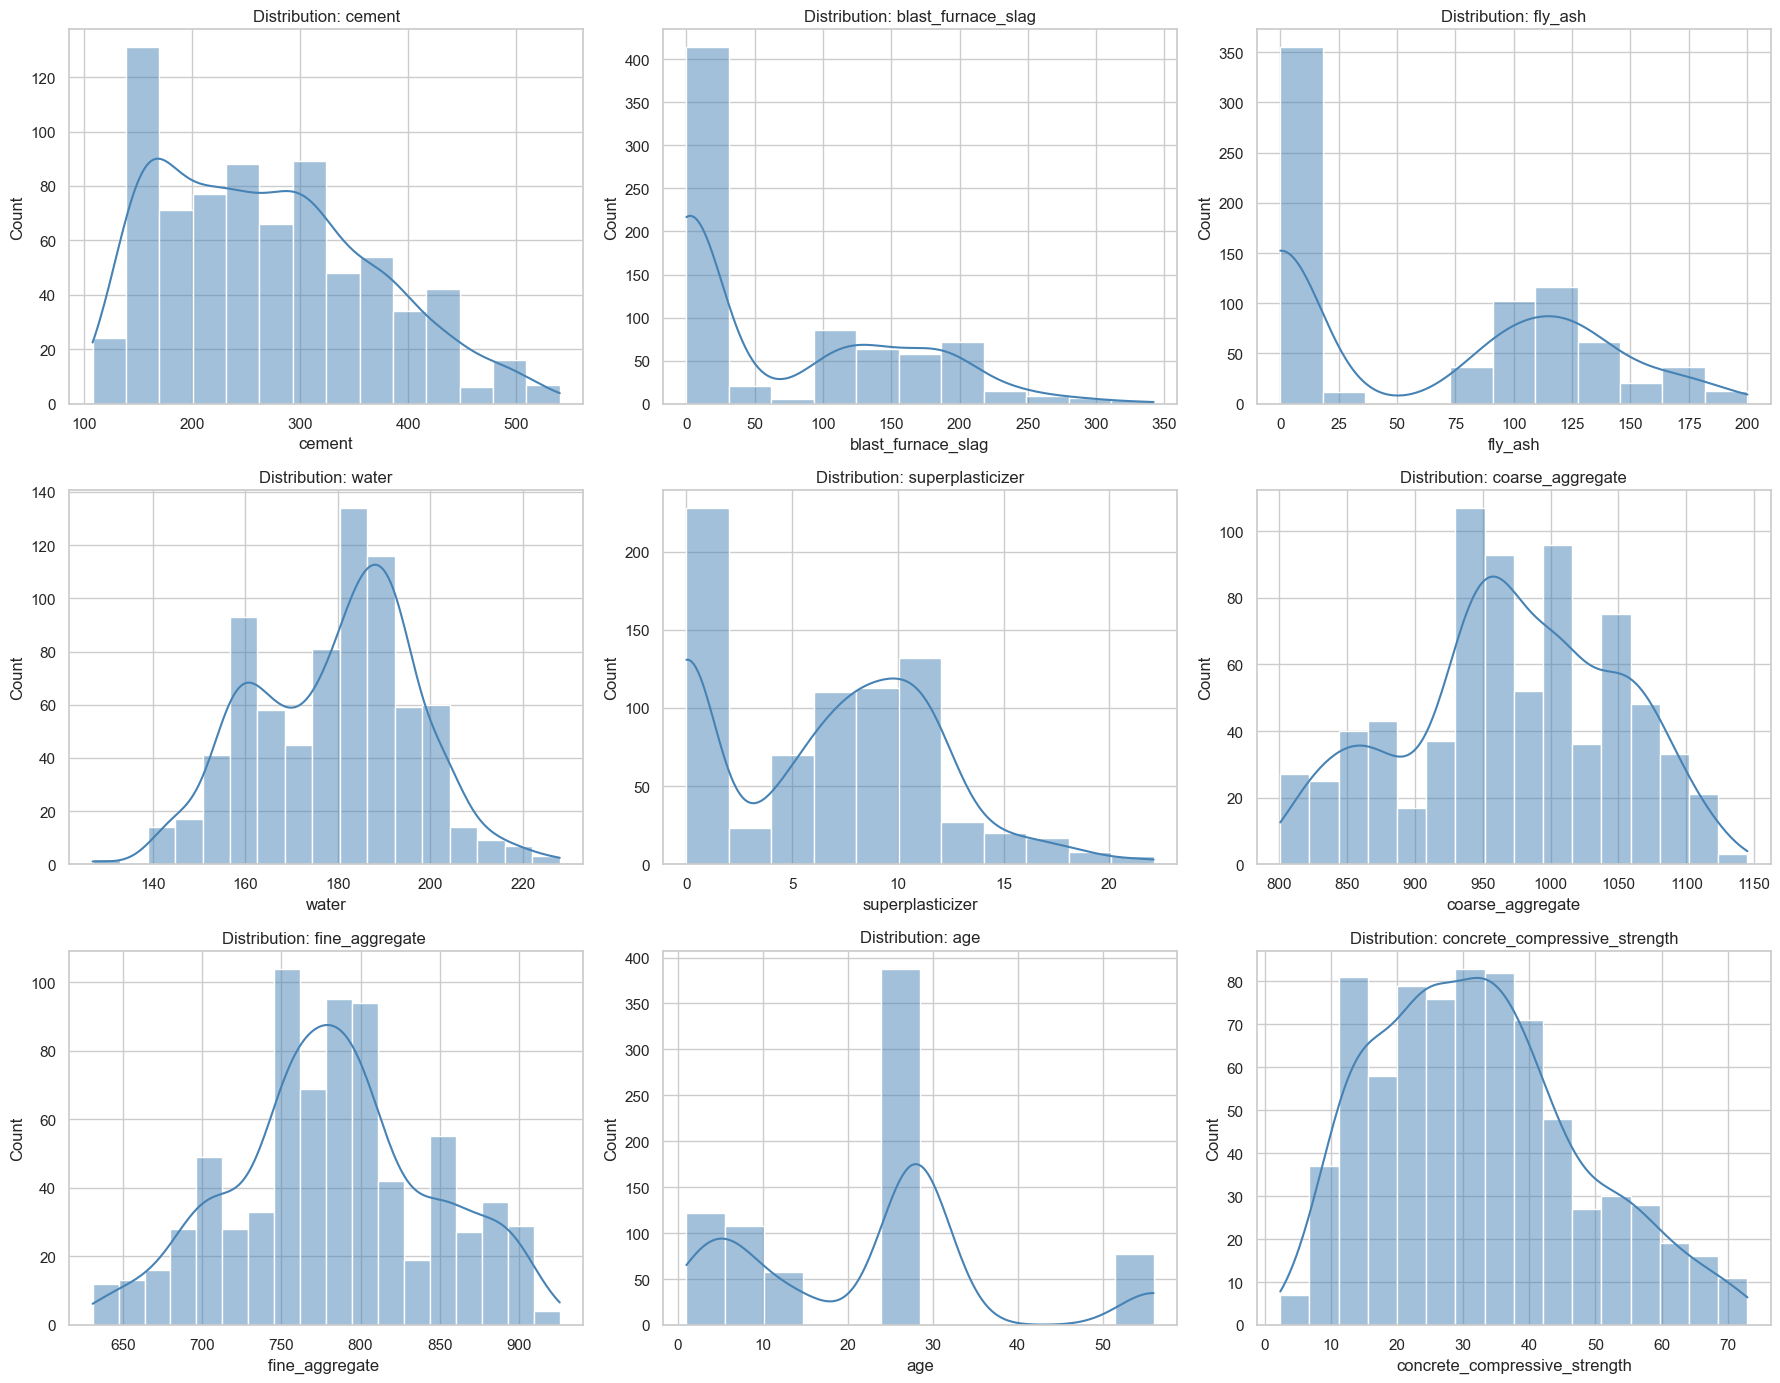

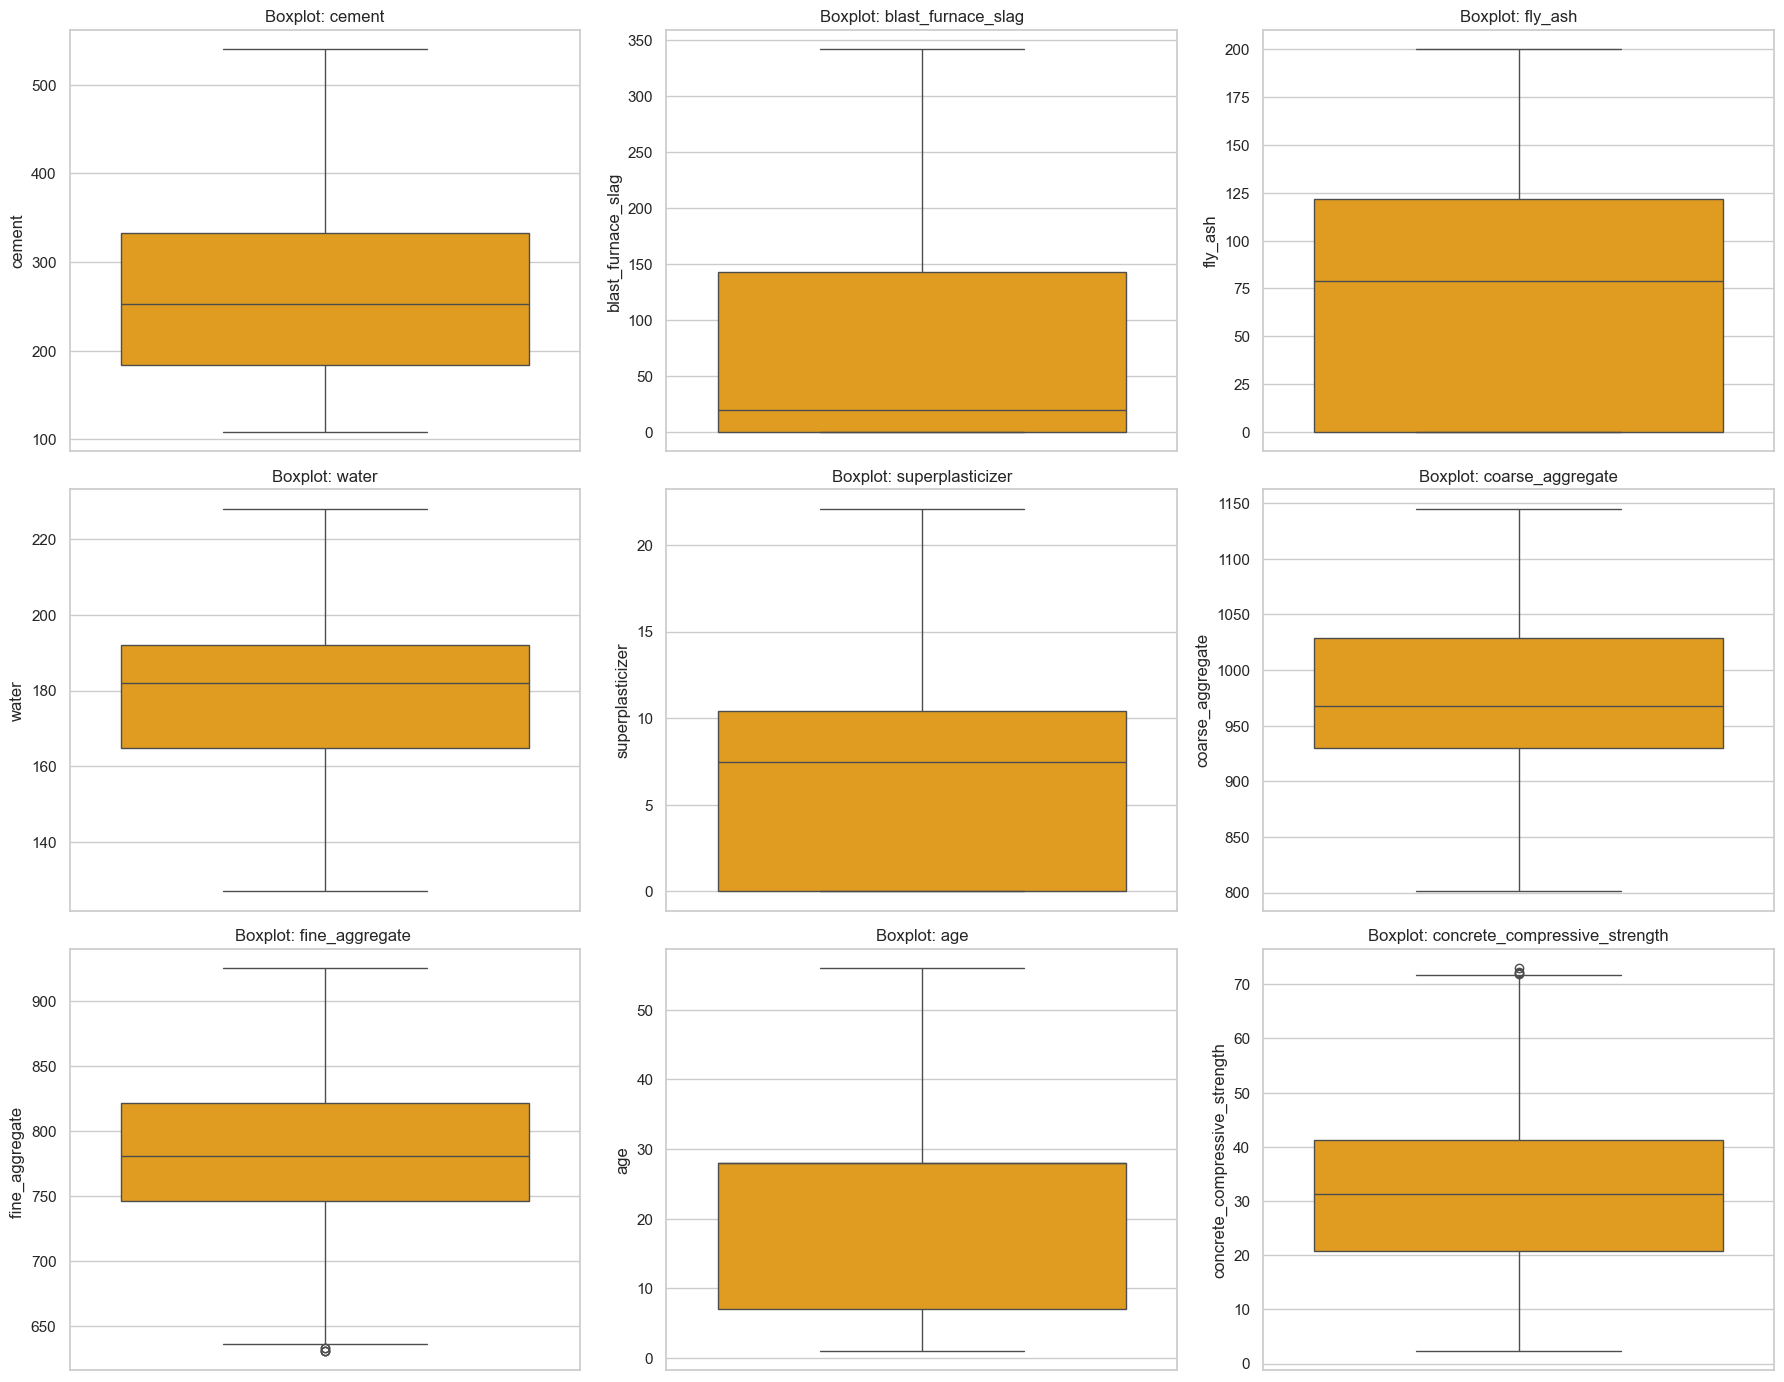

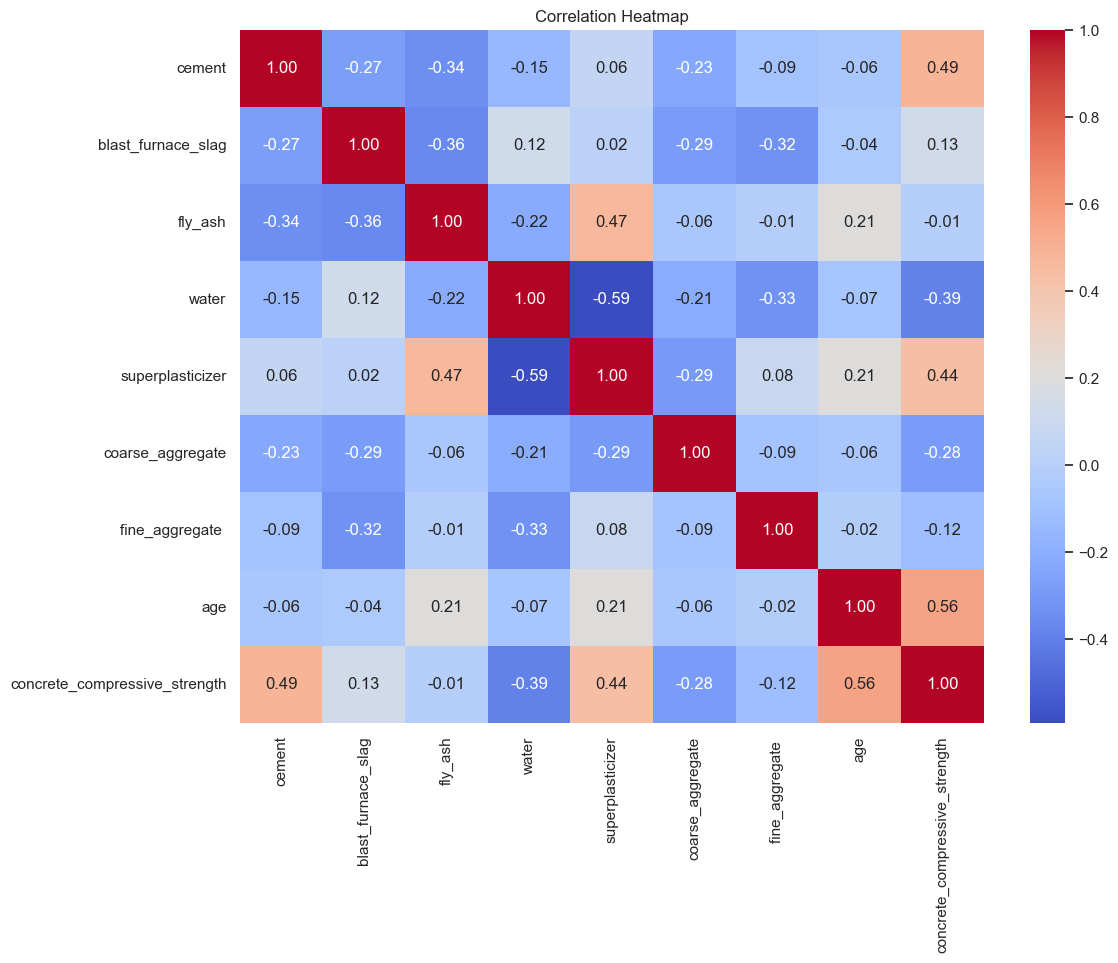

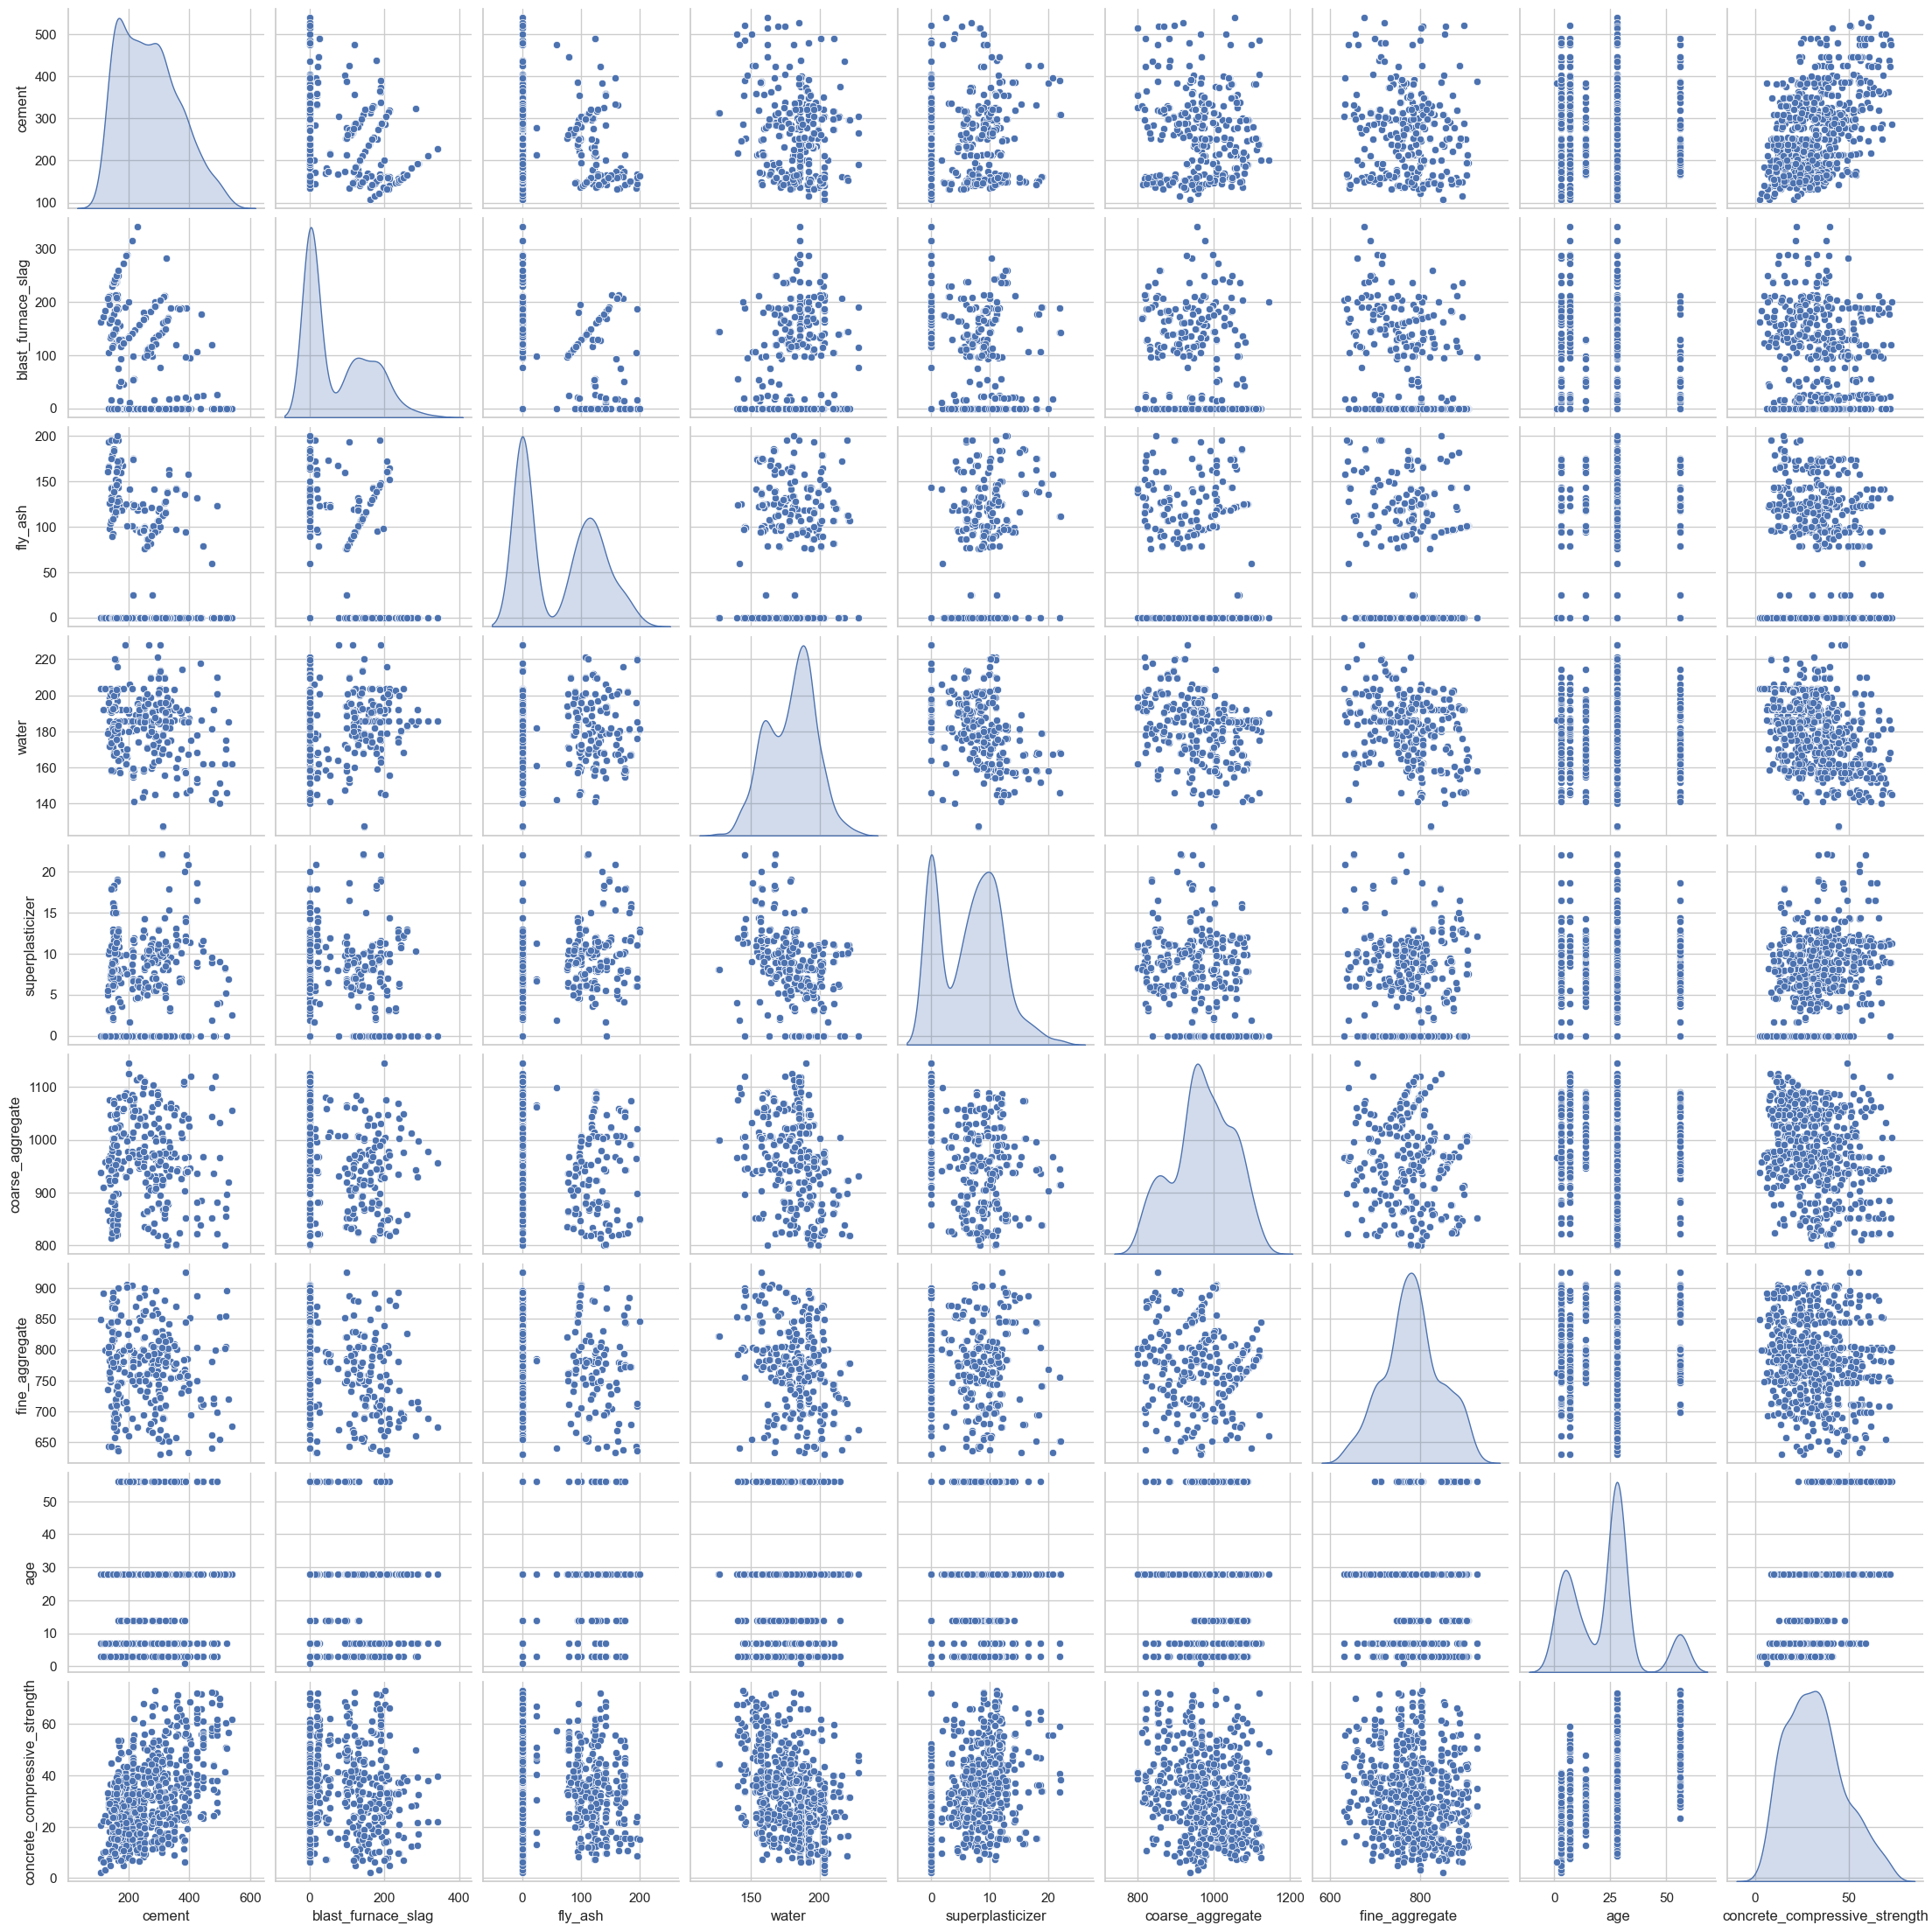

In [5]:
# %% [Cell 4] Visualizations - distributions, boxplots, heatmap, pairplot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution: {col}")
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot: {col}")
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df, diag_kind="kde")
plt.show()

In [7]:
# %% [Cell 5] Train-test split + scaling
target_col = "concrete_compressive_strength"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (602, 8)
X_test shape: (151, 8)


In [8]:
# %% [Cell 6] Train and compare models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train R2": round(train_r2, 4),
        "Test R2": round(test_r2, 4),
        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4),
        "Train MAE": round(train_mae, 4),
        "Test MAE": round(test_mae, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest Model: {best_model_name}")

               Model  Train R2  Test R2  Train RMSE  Test RMSE  Train MAE  \
0            XGBoost    0.9928   0.9404      1.3131     3.6084     0.2064   
1  Gradient Boosting    0.9515   0.9173      3.4034     4.2514     2.5201   
2      Random Forest    0.9799   0.8980      2.1906     4.7228     1.3711   
3              Ridge    0.7941   0.8170      7.0103     6.3257     5.3468   
4              Lasso    0.7941   0.8170      7.0105     6.3252     5.3489   
5  Linear Regression    0.7941   0.8162      7.0097     6.3387     5.3425   

   Test MAE  
0    2.4793  
1    3.2244  
2    3.3874  
3    4.8408  
4    4.8430  
5    4.8477  

Best Model: XGBoost


Best Model: XGBoost
Train R2: 0.9928 | Test R2: 0.9404
Train RMSE: 1.3131 | Test RMSE: 3.6084

Verdict: Good fit: train and test performance are close and reasonably high.


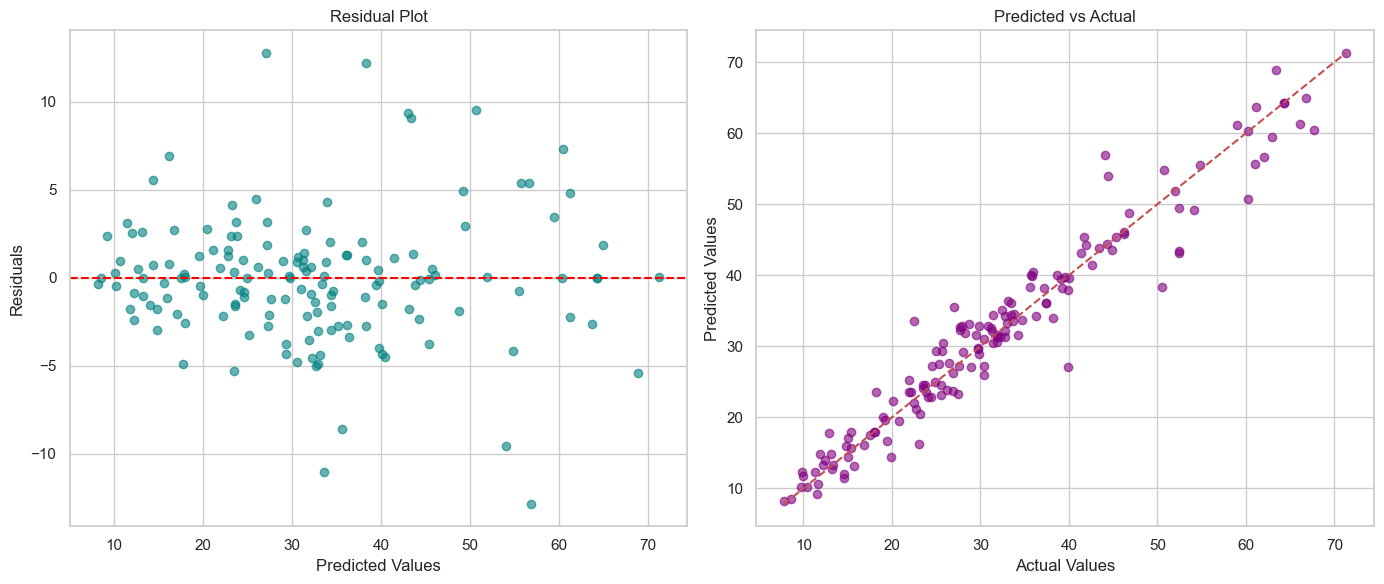

In [9]:
# %% [Cell 7] Overfitting/underfitting evaluation for best model
y_train_pred_best = best_model.predict(X_train_scaled)
y_test_pred_best = best_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred_best)
test_r2 = r2_score(y_test, y_test_pred_best)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Best Model: {best_model_name}")
print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

r2_gap = train_r2 - test_r2
if r2_gap > 0.15:
    verdict = "Overfitting: large gap between train and test R2."
elif train_r2 < 0.6 and test_r2 < 0.6:
    verdict = "Underfitting: both train and test R2 are low."
else:
    verdict = "Good fit: train and test performance are close and reasonably high."

print("\nVerdict:", verdict)

residuals = y_test - y_test_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_pred_best, residuals, alpha=0.6, color="teal")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot")

axes[1].scatter(y_test, y_test_pred_best, alpha=0.6, color="purple")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].set_title("Predicted vs Actual")

plt.tight_layout()
plt.show()

In [10]:
# %% [Cell 8] Test best model on 5 random test rows
sample_idx = X_test.sample(5, random_state=42).index
X_sample = X_test.loc[sample_idx]
X_sample_scaled = scaler.transform(X_sample)
y_actual_sample = y_test.loc[sample_idx]
y_pred_sample = best_model.predict(X_sample_scaled)

sample_results = pd.DataFrame({
    "Actual": y_actual_sample.values,
    "Predicted": y_pred_sample,
})
sample_results["Error %"] = ((sample_results["Predicted"] - sample_results["Actual"]) / sample_results["Actual"] * 100).round(2)
sample_results = sample_results.round(3)
print(sample_results)

   Actual  Predicted  Error %
0    8.54   8.529000    -0.13
1   20.08  22.268000    10.90
2   22.50  21.965000    -2.38
3   41.94  44.301998     5.63
4   41.67  45.438999     9.04


In [1]:
# %% [Cell 9] Manual input prediction
feature_names = X.columns.tolist()
print("Enter values for the following features:")

manual_values = []
for feat in feature_names:
    val = float(input(f"{feat}: "))
    manual_values.append(val)

manual_input_df = pd.DataFrame([manual_values], columns=feature_names)
manual_input_scaled = scaler.transform(manual_input_df)
predicted_strength = best_model.predict(manual_input_scaled)[0]

print(f"\nPredicted Concrete Compressive Strength: {predicted_strength:.3f}")

NameError: name 'X' is not defined

In [ ]:
# %% [Cell 10] Save model and scaler
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved best_model.pkl and scaler.pkl")